In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
MESMER_BEFORE = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_beforeREDSEA_gnn_predict.csv"
MESMER_AFTER  = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_afterREDSEA_gnn_predict.csv"

CD8_COL = "CD8"   # change if column name differs
BINS = 400
XMAX = 4

In [3]:
df_before = pd.read_csv(MESMER_BEFORE)
df_after  = pd.read_csv(MESMER_AFTER)

cd8_before = df_before[CD8_COL].dropna()
cd8_after  = df_after[CD8_COL].dropna()

xmin = min(cd8_before.min(), cd8_after.min())

In [12]:
df_test = pd.read_csv(MESMER_BEFORE)

In [14]:
print(list(df_test.columns))

['CD45RO', 'CD56', 'CD15', 'CD163', 'MUC2', 'CD34', 'CD36', 'aDefensin5', 'CD49a', 'HLA-DR', 'CD38', 'CollagenIV', 'CD4', 'CD138', 'CD44', 'Vimentin', 'CD66', 'Podoplanin', 'CHGA', 'CD3', 'SOX9', 'CD161', 'Synaptophysin', 'CD57', 'ITLN1', 'CD127', 'CD45', 'CD49f', 'aSMA', 'Cytokeratin', 'CD8', 'CD19', 'BCL2', 'CD90', 'CD21', 'CD7', 'CD11c', 'Ki67', 'CD68', 'MUC1', 'CD206', 'CD16', 'CD117', 'CD69', 'CD31', 'CD123', 'CDX2', 'slide_name', 'CellID', 'Unnamed: 0', 'cell_size', 'x_centroid', 'y_centroid', 'FILE', 'MUC6', 'GATA3', 'Lefty', 'CD279', 'NKG2D', 'CK7', 'PGP95', 'CD154', 'Somatostatin', 'CD294', 'DRAQ5', 'Hoechst1', 'leiden', 'pred_id', 'pred_name', 'pred_conf']


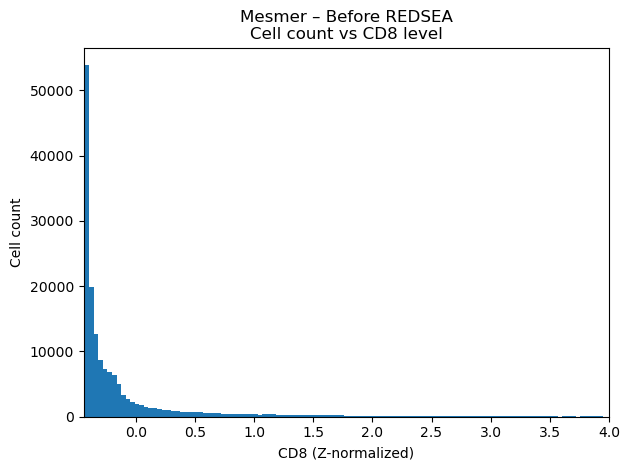

In [4]:
plt.figure()
plt.hist(cd8_before, bins=BINS)
plt.xlim(xmin, XMAX)
plt.xlabel("CD8 (Z-normalized)")
plt.ylabel("Cell count")
plt.title("Mesmer – Before REDSEA\nCell count vs CD8 level")
plt.tight_layout()
plt.show()

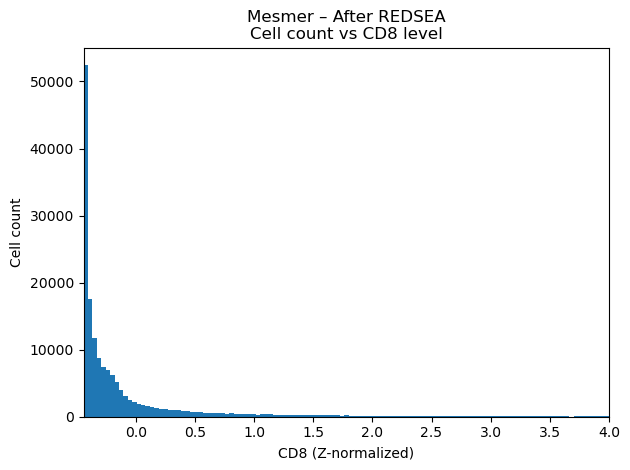

In [5]:
plt.figure()
plt.hist(cd8_after, bins=BINS)
plt.xlim(xmin, XMAX)
plt.xlabel("CD8 (Z-normalized)")
plt.ylabel("Cell count")
plt.title("Mesmer – After REDSEA\nCell count vs CD8 level")
plt.tight_layout()
plt.show()

In [2]:
MESMER_BEFORE = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_beforeREDSEA_gnn_predict.csv"
MESMER_AFTER  = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_afterREDSEA_gnn_predict.csv"

CD4_COL = "CD4"
CD8_COL = "CD8"
PRED_COL = "pred_name"

In [3]:
df_before = pd.read_csv(MESMER_BEFORE)
df_after  = pd.read_csv(MESMER_AFTER)

# Drop missing values
df_before = df_before[[CD4_COL, CD8_COL, PRED_COL]].dropna()
df_after  = df_after[[CD4_COL, CD8_COL, PRED_COL]].dropna()


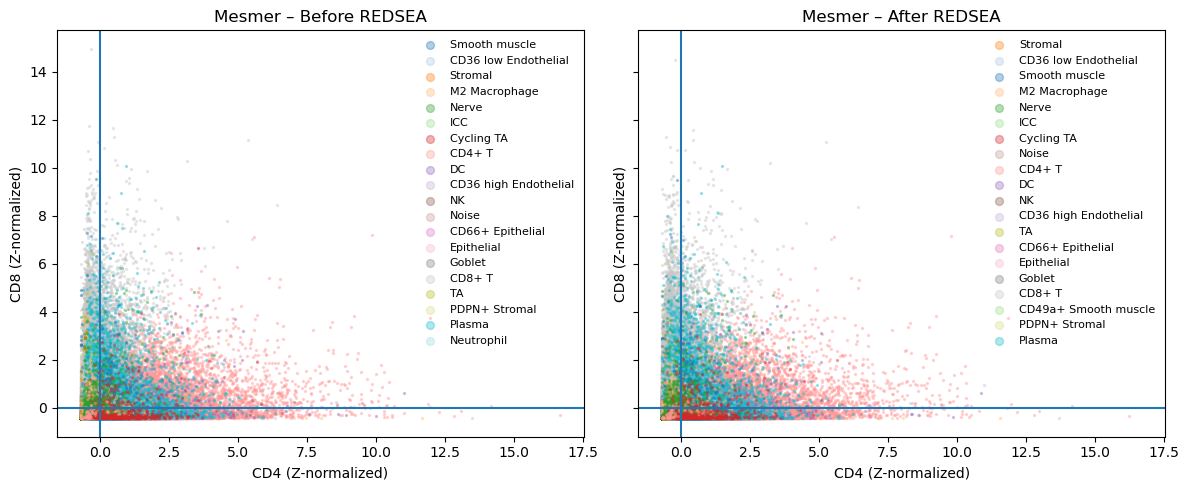

In [5]:
all_types = pd.Index(df_before[PRED_COL]).append(pd.Index(df_after[PRED_COL])).unique()
cmap = plt.get_cmap("tab20")  # categorical palette
color_map = {ct: cmap(i % cmap.N) for i, ct in enumerate(all_types)}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

def scatter_by_celltype(ax, df, title, show_legend=True, legend_max_items=20):
    # Plot each cell type separately so it gets its own color/legend entry
    for ct, g in df.groupby(PRED_COL, sort=False):
        ax.scatter(
            g[CD4_COL],
            g[CD8_COL],
            s=2,
            alpha=0.35,
            rasterized=True,
            c=[color_map[ct]],
            label=str(ct),
        )
    ax.axhline(0)
    ax.axvline(0)
    ax.set_title(title)
    ax.set_xlabel("CD4 (Z-normalized)")
    ax.set_ylabel("CD8 (Z-normalized)")

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > legend_max_items:
            # keep legend readable if there are lots of cell types
            handles = handles[:legend_max_items]
            labels = labels[:legend_max_items] + ["…"]
        ax.legend(
            handles,
            labels,
            markerscale=4,
            fontsize=8,
            frameon=False,
            loc="best"
        )

# ---- Before REDSEA ----
scatter_by_celltype(axes[0], df_before, "Mesmer – Before REDSEA", show_legend=True)

# ---- After REDSEA ----
scatter_by_celltype(axes[1], df_after, "Mesmer – After REDSEA", show_legend=True)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

MESMER_BEFORE = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_beforeREDSEA_gnn_predict.csv"
MESMER_AFTER  = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_afterREDSEA_gnn_predict.csv"

CLUSTER_COL = "leiden"


def _pick_feature_cols(df: pd.DataFrame, cluster_col: str) -> list[str]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [c for c in numeric_cols if c != cluster_col]


def compute_cluster_metrics(df: pd.DataFrame, cluster_col: str = "leiden", feature_cols=None) -> dict:
    if cluster_col not in df.columns:
        raise ValueError(f"'{cluster_col}' column not found.")

    if feature_cols is None:
        feature_cols = _pick_feature_cols(df, cluster_col)
    if len(feature_cols) == 0:
        raise ValueError("No numeric feature columns found.")

    work = df[feature_cols + [cluster_col]].dropna().copy()
    labels = work[cluster_col].to_numpy()
    X = work[feature_cols].to_numpy()

    out = {"Silhouette": np.nan, "Calinski–Harabasz": np.nan, "Davies–Bouldin": np.nan}

    if len(pd.unique(labels)) < 2 or X.shape[0] < 3:
        return out

    Xs = StandardScaler().fit_transform(X)

    try:
        out["Silhouette"] = float(silhouette_score(Xs, labels))
    except Exception:
        pass
    try:
        out["Calinski–Harabasz"] = float(calinski_harabasz_score(Xs, labels))
    except Exception:
        pass
    try:
        out["Davies–Bouldin"] = float(davies_bouldin_score(Xs, labels))
    except Exception:
        pass

    return out


def style_r_table(df: pd.DataFrame, caption: str | None = None):
    """
    R/gt-ish style: white background, no vertical borders, subtle horizontal rules,
    bold header, right-aligned numbers, compact row labels.
    """
    # Put metric names in a real column (R tables usually don't use an index visually)
    out = df.copy()
    out.insert(0, "Metric", out.index)
    out = out.reset_index(drop=True)

    styles = [
        # overall table
        {"selector": "table", "props": [
            ("background-color", "white"),
            ("border-collapse", "collapse"),
            ("font-family", "-apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Arial, sans-serif"),
            ("font-size", "14px"),
            ("line-height", "1.2"),
            ("border-top", "2px solid #222"),
            ("border-bottom", "2px solid #222"),
            ("width", "auto"),
        ]},
        # header row
        {"selector": "thead th", "props": [
            ("background-color", "white"),
            ("color", "#111"),
            ("font-weight", "700"),
            ("padding", "8px 12px"),
            ("border-bottom", "1px solid #222"),
            ("text-align", "left"),
        ]},
        # body cells
        {"selector": "tbody td", "props": [
            ("background-color", "white"),
            ("padding", "8px 12px"),
            ("border", "none"),                 # no vertical grid
            ("border-bottom", "1px solid #eee") # subtle horizontal rule
        ]},
        # last row bottom spacing (avoid extra rule vibe)
        {"selector": "tbody tr:last-child td", "props": [
            ("border-bottom", "none"),
        ]},
    ]

    sty = (
        out.style
        .format({c: "{:.4f}" for c in out.columns if c != "Metric"})
        .set_table_styles(styles)
        .set_properties(
            subset=["Metric"],
            **{
                "font-weight": "600",
                "text-align": "left",
                "white-space": "nowrap",
                "color": "#555",
            }
        )
        .set_properties(
            subset=[c for c in out.columns if c != "Metric"],
            **{
                "text-align": "right",
                "color": "#333",
            }
        )
        .hide(axis="index")
    )

    if caption:
        sty = sty.set_caption(caption).set_table_styles([
            *styles,
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("text-align", "left"),
                ("font-weight", "600"),
                ("margin-bottom", "6px"),
                ("color", "#111"),
            ]}
        ], overwrite=True)

    return sty


# ---- Load full dataframes ----
df_before = pd.read_csv(MESMER_BEFORE)
df_after  = pd.read_csv(MESMER_AFTER)

m_before = compute_cluster_metrics(df_before, cluster_col=CLUSTER_COL)
m_after  = compute_cluster_metrics(df_after,  cluster_col=CLUSTER_COL)

metrics_table = pd.DataFrame(
    {
        "Before REDSEA": m_before,
        "After REDSEA": m_after,
    }
)

# Pretty row labels
metrics_table.index = [
    "Silhouette (higher better)",
    "Calinski–Harabasz (higher better)",
    "Davies–Bouldin (lower better)",
]

display(style_r_table(metrics_table, caption="Clustering quality metrics"))


Metric,Before REDSEA,After REDSEA
Silhouette (higher better),-0.0124,-0.0354
Calinski–Harabasz (higher better),2833.6918,3001.4795
Davies–Bouldin (lower better),2.5496,2.5394
